# Rainbow book P&L attribution — the ATM-call book (sticky-strike)

The `rainbow_attribution.ipynb` study re-run on a different book: every joint
date sell one **\$1M 1Y at-the-money ranked-basket call** (strike 100,
uncapped) instead of the 100/112 call spread. Everything else is unchanged —
the basket `B = 0.5·best(SPX, SX5E) + 0.3·worst + 0.2·HSI`, the implied
marginals + constant Gaussian copula, the daily-sold ~260-vintage book, the
CRN Sobol engine at the 512-path book standard and the sticky-strike cut. The
only code difference is the payoff argument: `rainbow_attribution_ss(sds,
k_hi=np.inf)` turns the spread's `clamp(B − 1, 0, 0.12)` into the plain call
`max(B − 1, 0)` (expiry settlement at intrinsic uses the same payoff).

Driver: the third pass of `scripts/run_rainbow_attribution.py` → cache
`data/rainbow_attribution_ss_atm.csv` (532s on the GPU). The 512-path
standard was re-checked for the uncapped payoff before the run: a fresh ATM
vintage (\$75k on 2026-07-31) carries ~\$340 of per-contract scramble noise,
the same order as the spread, and a 30-day COVID slice at 512 vs 2,048 paths
agrees on every component total to <0.5% (only the gamma / `eq_resid` split
moves, ~\$25k on \$6M of gamma).

Components — same definitions as the spread notebook (independent
single-input revaluations off the t−1 close, sold-book sign, fixed lookup TTM
so term roll stays out of eq/vol):

| component | meaning |
|---|---|
| `eq` | all spots → t, sticky-strike: each index's implied distribution re-derived from its moneyness-shifted smile (vols pinned per strike) and its seasoning moved |
| `eq_delta/gamma/xgamma_*` | the eq move explained by the 1%-bump delta vector, gamma diagonal, and pair cross-gammas measured on the same book and CRN points; `eq_resid` = beyond-second-order |
| `vol`, `vol_<idx>` | surfaces → t **at fixed strikes** (day-t grids sampled at m/u), per-index singles; `vol_resid` = joint-move interaction |
| `cross_ev` | equity × vol cross by bumped revaluations (4-corner on the totals) |
| `theta_value` | discount-factor decay on the base pv (zero revaluations) |
| `theta_delta` | per-vintage SS deltas × each vintage's forward-ratio decay over dt (the carry of the delta position) |
| `theta_gamma` | the rest of `time` (gamma theta + vol carry) |
| `fwd`, `rate` | forward curves re-read at t (r−q carry); USD discount-factor change |
| `resid` | `pl` minus everything above |

The last section puts the ATM book next to the 100/112 spread book (both
caches are read). Analysis-only; total runtime is printed in the last cell.

In [1]:
import time
T0 = time.time()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

r = pd.read_csv("data/rainbow_attribution_ss_atm.csv", parse_dates=["date"],
                index_col="date")
cs = pd.read_csv("data/rainbow_attribution_ss.csv", parse_dates=["date"],
                 index_col="date")            # the 100/112 spread book
NAMES = ("spx", "sx5e", "hsi")
print(f"{len(r)} date pairs, {r.index[0].date()} -> {r.index[-1].date()}, "
      f"book {r['n_pos'].iloc[-1]} positions | premium sold "
      f"${r['premium'].sum() / 1e6:.1f}M (spread book "
      f"${cs['premium'].sum() / 1e6:.1f}M) | final mark "
      f"${r['mark'].iloc[-1] / 1e6:.2f}M")

1968 date pairs, 2018-12-28 -> 2026-07-31, book 259 positions | premium sold $133.9M (spread book $96.0M) | final mark $-27.97M


             total $M  daily std $k  corr with pl
pl            -114.95       1342.14          1.00
eq            -167.49       1370.60          0.99
eq_delta      -109.11       1386.75          0.99
eq_gamma       -49.09         57.49         -0.16
eq_xgamma       -8.65         38.77         -0.07
eq_resid        -0.65         13.86          0.01
vol            -22.02        146.38         -0.26
vol_spx        -14.66         93.38         -0.22
vol_sx5e        -6.58         65.39         -0.24
vol_hsi         -0.95         35.69         -0.05
vol_resid        0.17          1.24          0.10
cross_ev         6.20         27.92          0.05
time            71.21         27.66         -0.01
theta_value     -5.07          3.13          0.00
theta_delta      5.01         15.70         -0.01
theta_gamma     71.27         26.11         -0.01
fwd             -1.17         50.09          0.32
rate             0.05          4.11         -0.11
resid           -1.73          5.22          0.04


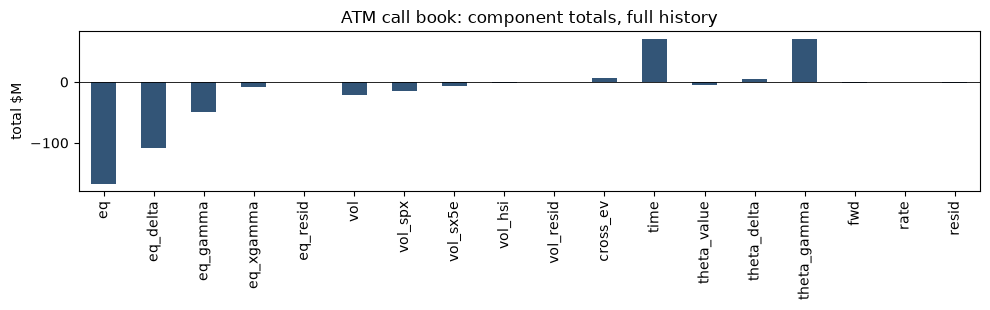

In [2]:
MAIN = ["pl", "eq", "eq_delta", "eq_gamma", "eq_xgamma", "eq_resid",
        "vol", "vol_spx", "vol_sx5e", "vol_hsi", "vol_resid", "cross_ev",
        "time", "theta_value", "theta_delta", "theta_gamma", "fwd", "rate",
        "resid"]
summ = pd.DataFrame({"total $M": r[MAIN].sum() / 1e6,
                     "daily std $k": r[MAIN].std() / 1e3,
                     "corr with pl": [np.corrcoef(r[c], r["pl"])[0, 1]
                                      for c in MAIN]})
print(summ.round(2).to_string())
fig, ax = plt.subplots(figsize=(10, 3.2))
(r[MAIN[1:]].sum() / 1e6).plot.bar(ax=ax, color="#357")
ax.set(ylabel="total $M", title="ATM call book: component totals, full history")
ax.axhline(0, color="k", lw=0.6)
plt.tight_layout()

Reading the table: the raw short book lost **−\$115.0M** against \$133.9M
of premium sold (mean \$68k per vintage vs \$49k for the spread) — and
**−\$109.1M of it is `eq_delta`** (SPX −\$70.0M, SX5E −\$30.9M, HSI −\$8.2M):
uncapped calls sold into a seven-year rally, where every deep-ITM vintage
keeps a delta near one instead of decaying to zero above the spread's cap.
Below the delta line the ATM book is a different animal from the spread:

- **The gamma–theta trade is large and real.** `theta_gamma` **+\$71.3M**
  (+\$36k/day, positive in every calendar year) against `eq_gamma`
  **−\$49.1M** and `eq_xgamma` **−\$8.7M** — the book earned \$13.5M more
  theta than it paid in realized gamma. On the spread both sides are small
  (+\$0.5M theta vs −\$4.8M gamma + cross).
- **Cross-gamma flips sign.** Every pair is now a loss (SPX–SX5E −\$2.1M,
  SPX–HSI −\$2.5M, SX5E–HSI −\$4.0M): with no cap, the basket call's
  convexity makes it long every pair, and the sold book pays on co-moves. The
  rank kink still shows: SPX–SX5E has the largest weight product and the
  highest copula correlation (0.75), yet it's the *smallest* of the three
  losses — the kink that made it +\$3.2M on the spread partly offsets it.
- **Vega is no longer a wash.** `vol` **−\$22.0M** (vs −\$0.3M on the
  spread) at \$146k daily std: an ATM book is net short vega, which on the
  spread the long 112 leg largely offset. The vol section below shows what
  drives it.
- `cross_ev` flips to **+\$6.2M** (spread −\$6.6M), and the −\$5.1M of
  `theta_value` financing is almost exactly paid back by `theta_delta`
  +\$5.0M (the forward carry of a much larger delta position).

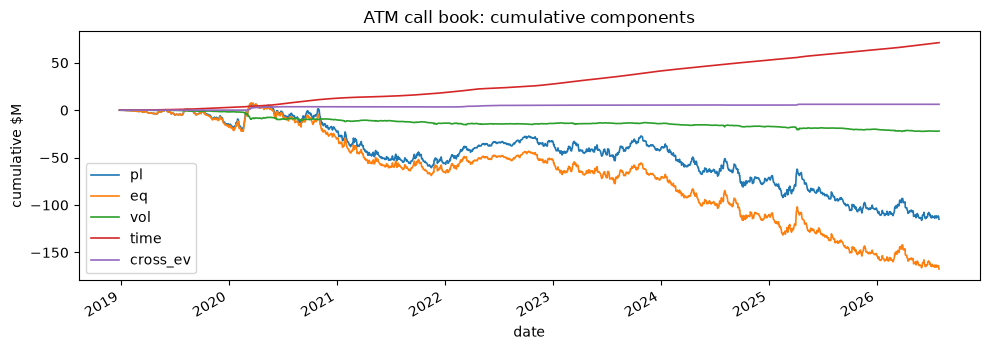

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.6))
for c in ["pl", "eq", "vol", "time", "cross_ev"]:
    (r[c].cumsum() / 1e6).plot(ax=ax, lw=1.2, label=c)
ax.legend()
ax.set(ylabel="cumulative $M", title="ATM call book: cumulative components")
plt.tight_layout()

## The delta-hedged book — the desk view

Same convention as the spread notebook: the desk keeps
`pl − eq_delta − theta_value − theta_delta`. The delta P&L is hedged away
(`eq_delta`); the interest on the option's market value (`theta_value`,
−\$5.1M) accrues to the treasury desk against the premium cash; and
`theta_delta` (+\$5.0M) is the forward-roll gain on the option position that
pays the delta-one desk's funding charge on the hedge. The only theta the desk
keeps is **`theta_gamma`**. The small remainder (`eq_resid`, `rate`,
`resid`) is grouped as *other*; everything sums to the black total.

excluded carry: theta_value -5.07M (treasury) + theta_delta +5.01M (pays the delta funding) = -0.06M
                          total $M  std $k  median $  skew  worst $M
desk delta-hedged            -5.79  181.52   9199.57 -3.97     -2.22
after delta+gamma matrix     51.95  141.57  23011.01 -0.38     -1.22


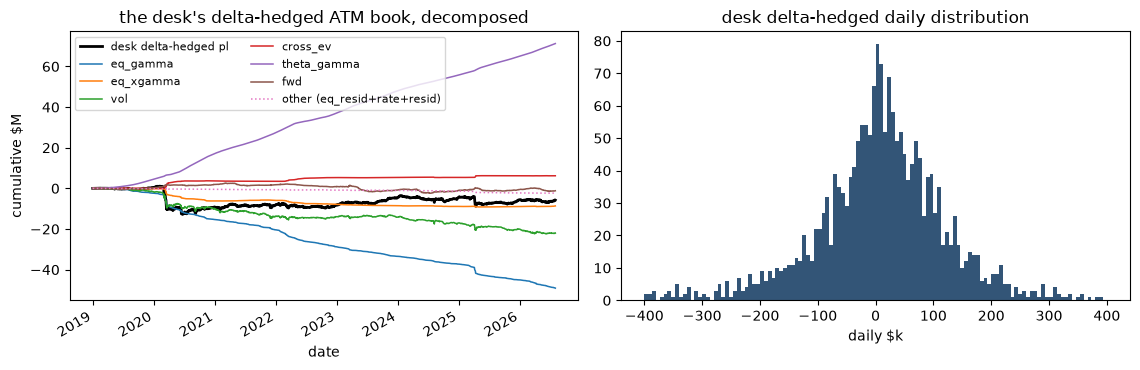

In [4]:
h = r["pl"] - r[["eq_delta", "theta_value", "theta_delta"]].sum(axis=1)
hg = h - r["eq_gamma"] - r["eq_xgamma"]
comps = ["eq_gamma", "eq_xgamma", "vol", "cross_ev", "theta_gamma",
         "fwd"]
other = h - r[comps].sum(axis=1)                  # eq_resid + rate + resid
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
(h.cumsum() / 1e6).plot(ax=ax[0], color="k", lw=2,
                        label="desk delta-hedged pl")
for c in comps:
    (r[c].cumsum() / 1e6).plot(ax=ax[0], lw=1.1, label=c)
(other.cumsum() / 1e6).plot(ax=ax[0], lw=1.1, ls=":",
                            label="other (eq_resid+rate+resid)")
ax[0].legend(fontsize=8, ncol=2)
ax[0].set(ylabel="cumulative $M",
          title="the desk's delta-hedged ATM book, decomposed")
ax[1].hist(h / 1e3, bins=120, range=(-400, 400), color="#357")
ax[1].set(xlabel="daily $k", title="desk delta-hedged daily distribution")
plt.tight_layout()
carry = r["theta_value"] + r["theta_delta"]
print(f"excluded carry: theta_value {r['theta_value'].sum() / 1e6:+.2f}M "
      f"(treasury) + theta_delta {r['theta_delta'].sum() / 1e6:+.2f}M "
      f"(pays the delta funding) = {carry.sum() / 1e6:+.2f}M")
print(pd.DataFrame({"total $M": [h.sum() / 1e6, hg.sum() / 1e6],
                    "std $k": [h.std() / 1e3, hg.std() / 1e3],
                    "median $": [h.median(), hg.median()],
                    "skew": [h.skew(), hg.skew()],
                    "worst $M": [h.min() / 1e6, hg.min() / 1e6]},
                   index=["desk delta-hedged", "after delta+gamma matrix"])
      .round(2).to_string())

The desk's delta-hedged ATM book loses only **−\$5.8M** over the sample,
but at **\$182k daily std** — about twice the spread's \$94k — with a
*positive* median (+\$9.2k/day: the theta harvest) and skew −4.0. The
carry-inclusive cut `pl − eq_delta` is the same −\$5.8M at the same std (on
this book the two excluded carry lines net to −\$0.06M). The loss is all
COVID: the 2020-02-20 → 04-03 window costs −\$10.8M and the rest of the
history makes +\$5.0M. The worst day is 2020-03-09 (−\$2.2M), with
2025-04-07 (−\$2.0M) a close second.

After the gamma matrix the residual has skew −0.4 (vs −4.0 delta-only), so
as on the spread the crash tail is second-order equity risk explained by the
19 pricings. The matrix takes out less of the variance here, though (std
\$182k → \$142k, vs \$94k → \$67k on the spread), because the biggest line
left is vol (\$146k std).

## How good is the 1%-bump Taylor across seven years?

eq_resid: cumulative $-0.65M over 1968 days | std $13,856 (1.0% of pl std) | big-day std $52,045 | worst $433,857 on 2020-03-12
gamma by index ($M): {'spx': -25.35, 'sx5e': -20.61, 'hsi': -3.13}
xgamma by pair ($M): {'spx_sx5e': -2.13, 'spx_hsi': -2.54, 'sx5e_hsi': -3.97}


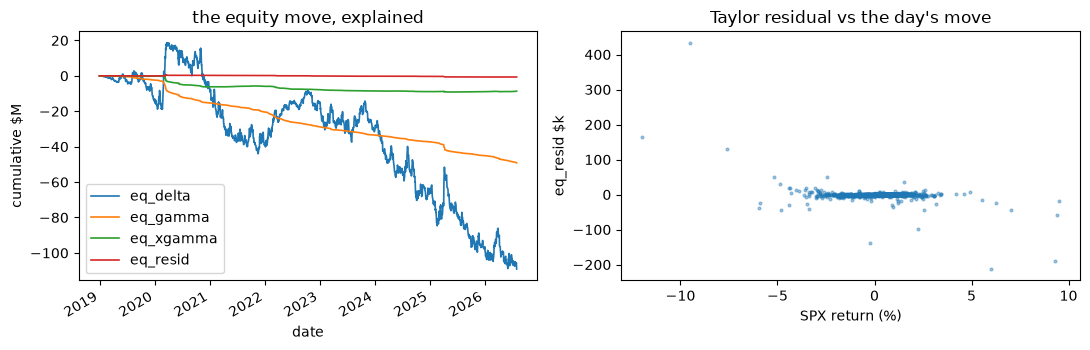

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for c in ["eq_delta", "eq_gamma", "eq_xgamma", "eq_resid"]:
    (r[c].cumsum() / 1e6).plot(ax=ax[0], lw=1.2, label=c)
ax[0].legend()
ax[0].set(ylabel="cumulative $M", title="the equity move, explained")
ax[1].scatter(100 * r["ret_spx"], r["eq_resid"] / 1e3, s=4, alpha=0.4)
ax[1].set(xlabel="SPX return (%)", ylabel="eq_resid $k",
          title="Taylor residual vs the day's move")
plt.tight_layout()
big = r["ret_spx"].abs() > 0.02
print(f"eq_resid: cumulative ${r['eq_resid'].sum() / 1e6:+.2f}M over "
      f"{len(r)} days | std ${r['eq_resid'].std():,.0f} "
      f"({r['eq_resid'].std() / r['pl'].std():.1%} of pl std) | "
      f"big-day std ${r.loc[big, 'eq_resid'].std():,.0f} | worst "
      f"${r['eq_resid'].abs().max():,.0f} on "
      f"{r['eq_resid'].abs().idxmax().date()}")
print("gamma by index ($M):",
      {k.replace('eq_gamma_', ''): round(v / 1e6, 2)
       for k, v in r[[f"eq_gamma_{n}" for n in NAMES]].sum().items()})
print("xgamma by pair ($M):",
      {k.replace('eq_xgamma_', ''): round(v / 1e6, 2)
       for k, v in r[[c for c in r.columns
                      if c.startswith('eq_xgamma_')]].sum().items()})

As good as on the spread: the residual beyond delta+gamma+cross totals
**−\$0.65M over 7.6 years** against −\$167.5M of equity P&L, std \$13.9k
(1.0% of P&L std), big-day std \$52k, worst \$434k on 2020-03-12 — the same
cubic big-move shape. The gamma diagonal loses on every index
(SPX −\$25.4M, SX5E −\$20.6M, HSI −\$3.1M; on the spread HSI gamma was a
+\$1.4M gain).

## Vol at fixed strikes, and the theta split

vol totals $M: {'vol_spx': -14.66, 'vol_sx5e': -6.58, 'vol_hsi': -0.95, 'vol_resid': 0.17}
vol daily std $k: {'vol_spx': 93.4, 'vol_sx5e': 65.4, 'vol_hsi': 35.7, 'vol_resid': 1.2}
theta means $k/day: {'theta_value': -2.58, 'theta_delta': 2.55, 'theta_gamma': 36.21}


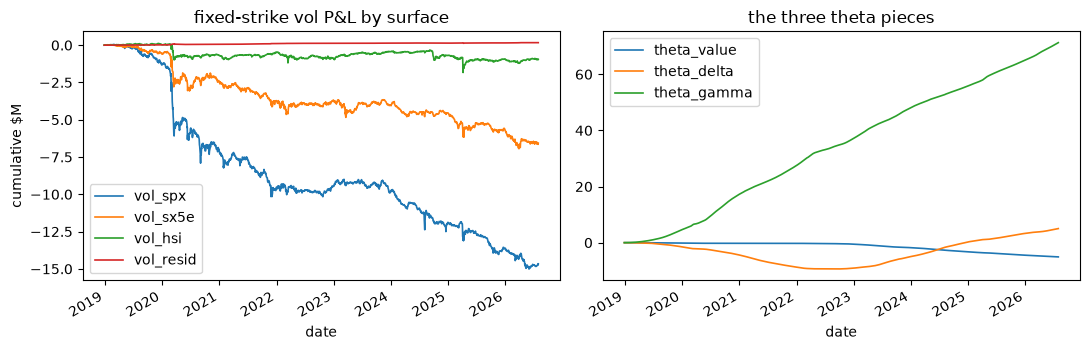

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for c in ["vol_spx", "vol_sx5e", "vol_hsi", "vol_resid"]:
    (r[c].cumsum() / 1e6).plot(ax=ax[0], lw=1.2, label=c)
ax[0].legend()
ax[0].set(ylabel="cumulative $M", title="fixed-strike vol P&L by surface")
for c in ["theta_value", "theta_delta", "theta_gamma"]:
    (r[c].cumsum() / 1e6).plot(ax=ax[1], lw=1.2, label=c)
ax[1].legend()
ax[1].set(title="the three theta pieces")
plt.tight_layout()
print("vol totals $M:", (r[["vol_spx", "vol_sx5e", "vol_hsi", "vol_resid"]]
                         .sum() / 1e6).round(2).to_dict())
print("vol daily std $k:", (r[["vol_spx", "vol_sx5e", "vol_hsi",
                               "vol_resid"]].std() / 1e3).round(1).to_dict())
print("theta means $k/day:",
      (r[["theta_value", "theta_delta", "theta_gamma"]].mean() / 1e3)
      .round(2).to_dict())

The vol line is where the ATM book differs most from the spread. Every
surface loses (SPX −\$14.7M, SX5E −\$6.6M, HSI −\$1.0M), every year
2019–2026 is negative (2020 alone −\$8.4M), and the joint-move residual stays
negligible (\$1.2k std).

The regression below says what drives it: fixed-strike vols jump after big
moves *in either direction*. The day's three returns plus their squares
explain 29% of the vol line's variance, and the squared-return term alone
carries −\$32.9M. On quiet days (all three |ret| < 0.5%) the short vega
*earns* +\$8.3k/day, while the >2% SPX down days cost −\$17.5M. So on this
book the vol line is largely second-order equity risk in disguise, not an
independent vol bet.

It also leaves the delta-hedged book with a market beta: corr(desk P&L,
SPX) is +0.33 here vs +0.14 on the spread. Fixed-strike vols fall on up days,
and the sticky-strike delta (vols pinned per strike) doesn't see that.

The theta pieces: `theta_value` (−\$2.6k/day) and `theta_delta`
(+\$2.5k/day) nearly cancel, and `theta_gamma`, +\$36.2k/day at \$26k daily
std, is the line that pays for the gamma.

In [7]:
R = r[["ret_spx", "ret_sx5e", "ret_hsi"]].to_numpy()
y = r["vol"].to_numpy()
for lab, X in [("returns", np.column_stack([np.ones(len(r)), R])),
               ("returns + squares", np.column_stack([np.ones(len(r)), R,
                                                      R ** 2]))]:
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    fit = X @ b
    r2 = 1 - ((y - fit) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    sq = (X[:, 4:] @ b[4:]).sum() / 1e6 if X.shape[1] > 4 else 0.0
    print(f"vol ~ {lab:18s} R2 {r2:.3f} | cumulative $M: intercept "
          f"{b[0] * len(r) / 1e6:+.1f}, linear {(X[:, 1:4] @ b[1:4]).sum() / 1e6:+.1f}, "
          f"squared {sq:+.1f}")
quiet = (np.abs(R) < 0.005).all(1)
print(f"quiet days (all |ret| < 0.5%): {quiet.sum()} days, vol mean "
      f"${y[quiet].mean() / 1e3:+.1f}k/day | SPX < -2% days: vol "
      f"${y[r['ret_spx'] < -0.02].sum() / 1e6:+.1f}M | SPX > +2% days: "
      f"${y[r['ret_spx'] > 0.02].sum() / 1e6:+.1f}M")
print("vol by year $M:", (r["vol"].groupby(r.index.year).sum() / 1e6)
      .round(2).to_dict())

vol ~ returns            R2 0.210 | cumulative $M: intercept -28.7, linear +6.6, squared +0.0
vol ~ returns + squares  R2 0.292 | cumulative $M: intercept +4.7, linear +6.2, squared -32.9
quiet days (all |ret| < 0.5%): 225 days, vol mean $+8.3k/day | SPX < -2% days: vol $-17.5M | SPX > +2% days: $+6.0M
vol by year $M: {2018: 0.0, 2019: -1.81, 2020: -8.36, 2021: -3.45, 2022: -0.3, 2023: -0.21, 2024: -2.85, 2025: -3.15, 2026: -1.9}


## COVID, day by day

The raw short book *made* \$26.3M in the window (the short delta paid
+\$37.3M); everything the desk keeps lost money — gamma −\$6.1M, cross-gamma
−\$3.1M, vol −\$6.1M — partly offset by `cross_ev` +\$2.8M and theta
+\$0.8M, for −\$10.8M on the desk's delta-hedged view.

COVID window totals $M: {'pl': 26.25, 'eq_delta': 37.26, 'eq_gamma': -6.08, 'eq_xgamma': -3.13, 'vol': -6.08, 'cross_ev': 2.76, 'time': 0.83}


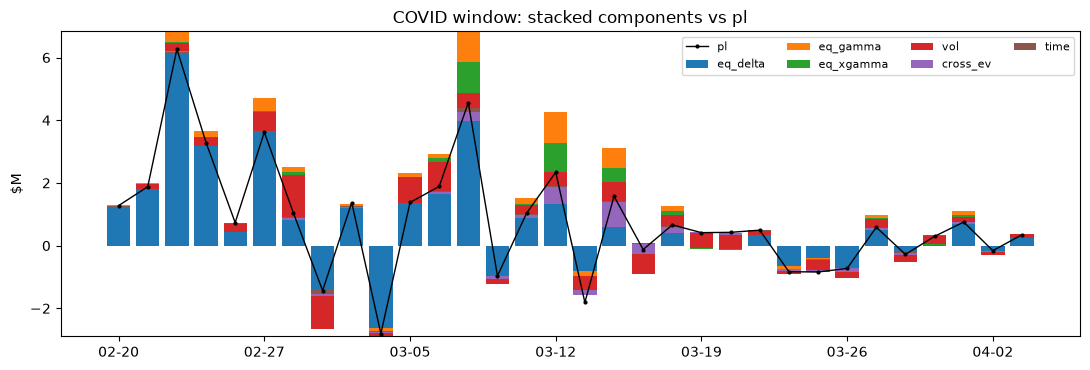

In [8]:
w = r.loc["2020-02-20":"2020-04-03",
          ["eq_delta", "eq_gamma", "eq_xgamma", "vol", "cross_ev", "time"]]
fig, ax = plt.subplots(figsize=(11, 3.8))
bot = np.zeros(len(w))
for c in w.columns:
    ax.bar(range(len(w)), w[c] / 1e6, bottom=bot, label=c, width=0.8)
    bot += w[c] / 1e6
ax.plot(range(len(w)), r.loc[w.index, "pl"] / 1e6, "k.-", lw=1, ms=4,
        label="pl")
ax.set_xticks(range(0, len(w), 5))
ax.set_xticklabels([d.strftime("%m-%d") for d in w.index[::5]])
ax.legend(fontsize=8, ncol=4)
ax.set(ylabel="$M", title="COVID window: stacked components vs pl")
plt.tight_layout()
print("COVID window totals $M:",
      (r.loc[w.index, ["pl"] + list(w.columns)].sum() / 1e6).round(2)
      .to_dict())

Identity check and the worst residual days (same asserts as the spread
notebook):

In [9]:
tay = r[["eq_delta", "eq_gamma", "eq_xgamma", "eq_resid"]].sum(axis=1)
th = r[["theta_value", "theta_delta", "theta_gamma"]].sum(axis=1)
top = r[["eq", "vol", "cross_ev", "time", "fwd", "rate", "resid"]].sum(axis=1)
assert np.allclose(tay, r["eq"], atol=1e-6)
assert np.allclose(th, r["time"], atol=1e-6)
assert np.allclose(top, r["pl"], atol=1e-6)
print(f"identities exact | resid std ${r['resid'].std():,.0f} = "
      f"{r['resid'].std() / r['pl'].std():.2%} of pl std, worst "
      f"${r['resid'].abs().max():,.0f} on {r['resid'].abs().idxmax().date()}")
print("\nworst-|resid| days:")
cols = ["pl", "eq", "vol", "cross_ev", "time", "resid", "ret_spx"]
print(r.reindex(r["resid"].abs().sort_values(ascending=False).index[:5])[cols]
      .round(0).to_string())

identities exact | resid std $5,225 = 0.39% of pl std, worst $129,292 on 2020-03-09

worst-|resid| days:
                   pl         eq        vol  cross_ev      time     resid  ret_spx
date                                                                              
2020-03-09  4561981.0  5000627.0  -883564.0  276910.0  125874.0 -129292.0     -0.0
2025-04-07  5527350.0  6417205.0 -1484492.0  209532.0  133815.0  -98776.0     -0.0
2022-03-07  1330358.0  1401578.0  -250425.0   66194.0  116140.0  -41790.0     -0.0
2019-08-23  1475026.0  1235094.0  -168296.0   20732.0   10903.0  -40698.0     -0.0
2022-01-24  2293276.0  2465500.0  -256791.0   23445.0   97573.0   30092.0      0.0


## The ATM call next to the 100/112 spread

Same basket, copula, engine, book schedule and attribution — only the cap
differs.

totals $M
                   ATM call  100/112 spread
premium              133.86           95.95
pl                  -114.95          -65.71
eq_delta            -109.11          -52.12
eq_gamma             -49.09           -8.00
eq_xgamma             -8.65            3.20
vol                  -22.02           -0.32
cross_ev               6.20           -6.57
theta_gamma           71.27            0.48
theta_value           -5.07           -3.52
theta_delta            5.01            1.44
desk delta-hedged     -5.79          -11.51

risk
                           ATM call  100/112 spread
pl std $k                   1342.14          676.82
desk hedged std $k           181.52           94.05
after gamma matrix std $k    141.57           67.54
vol std $k                   146.38           61.80
desk hedged skew              -3.97           -6.22
worst desk day $M             -2.22           -1.47
corr(desk, ret_spx)            0.33            0.14


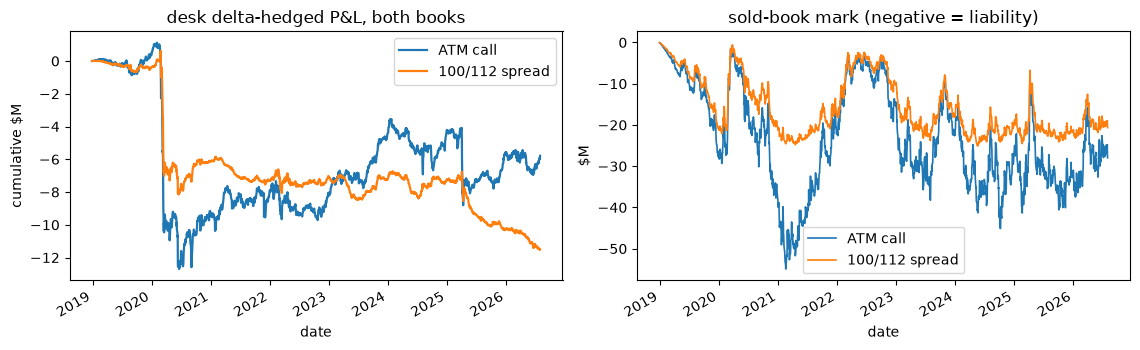

In [10]:
def desk(x):
    return x["pl"] - x[["eq_delta", "theta_value", "theta_delta"]].sum(axis=1)

books = {"ATM call": r, "100/112 spread": cs}
rows = ["premium", "pl", "eq_delta", "eq_gamma", "eq_xgamma", "vol",
        "cross_ev", "theta_gamma", "theta_value", "theta_delta"]
tot = pd.DataFrame({k: x[rows].sum() / 1e6 for k, x in books.items()})
tot.loc["desk delta-hedged"] = [desk(x).sum() / 1e6 for x in books.values()]
print("totals $M\n" + tot.round(2).to_string())
sd = pd.DataFrame({k: [x["pl"].std() / 1e3, desk(x).std() / 1e3,
                       (desk(x) - x["eq_gamma"] - x["eq_xgamma"]).std() / 1e3,
                       x["vol"].std() / 1e3, desk(x).skew(),
                       desk(x).min() / 1e6,
                       np.corrcoef(desk(x), x["ret_spx"])[0, 1]]
                   for k, x in books.items()},
                  index=["pl std $k", "desk hedged std $k",
                         "after gamma matrix std $k", "vol std $k",
                         "desk hedged skew",
                         "worst desk day $M", "corr(desk, ret_spx)"])
print("\nrisk\n" + sd.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
for k, x in books.items():
    (desk(x).cumsum() / 1e6).plot(ax=ax[0], lw=1.6, label=k)
    (x["mark"] / 1e6).plot(ax=ax[1], lw=1.2, label=k)
ax[0].legend()
ax[0].set(ylabel="cumulative $M", title="desk delta-hedged P&L, both books")
ax[1].legend()
ax[1].set(ylabel="$M", title="sold-book mark (negative = liability)")
plt.tight_layout()

The ATM book takes in 1.4× the premium but runs 2.0× the raw P&L std
(\$1.34M vs \$677k) and 1.9× the desk-hedged std. The spread's cap is what
made its hedged economics a crash-gamma story with a negligible vol line.
Without the cap the book becomes a classic short-variance position: a
+\$13.5M theta-minus-gamma harvest that the vol marks — themselves driven by
the size of the day's move — eat, with COVID deciding the sign of the total.
Both books' final marks are deep liabilities after the rally (−\$28.0M ATM
vs −\$20.6M spread).

## Takeaways

- Same machinery, one-argument change (`k_hi=np.inf`), same quality: the
  top-level residual is \$5.2k std = 0.39% of P&L std, and the equity Taylor
  residual is 1.0% of P&L std with no drift.
- ATM-book economics: −\$115M raw (−\$109M of it unhedged delta into the
  rally). The desk's delta-hedged book is −\$5.8M at \$182k std: +\$71.3M of
  gamma theta against −\$57.7M of realized gamma + cross-gamma, −\$22.0M of
  vol, +\$6.2M of `cross_ev`. COVID's six weeks cost −\$10.8M; the rest of the
  history made +\$5.0M.
- What changes vs the spread, and matters for cheap VaR on this book: vega
  is a first-class risk (vol std \$146k, larger than either gamma line), the
  cross-gammas flip sign, and the sticky-strike delta leaves a residual SPX
  beta (corr 0.33) running through the vol line. The SS-hedges-best verdict
  (`rainbow_greeks.ipynb`, −43% hedged std) was measured on the spread book;
  re-measure it here before assuming it for an ATM book.

In [11]:
print(f"total notebook runtime: {time.time() - T0:.1f}s (analysis-only; "
      f"the GPU compute lives in scripts/run_rainbow_attribution.py)")

total notebook runtime: 1.9s (analysis-only; the GPU compute lives in scripts/run_rainbow_attribution.py)
